In [1]:
import warnings
from pathlib import Path

In [2]:
# basic imports
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# incidencia_delictiva imports
from incidencia_delictiva.config import (
    PROJ_ROOT, 
    DATA_DIR,
    PROCESSED_DATA_DIR
)

In [5]:
# configs
sns.set_theme(style='darkgrid')
warnings.filterwarnings('ignore')

In [6]:
dataset_baseline_path = PROCESSED_DATA_DIR / "dataset_baseline.parquet"
assert dataset_baseline_path.exists() and dataset_baseline_path.is_file()

df = pd.read_parquet(dataset_baseline_path)

In [7]:
df.head()

,año,cvegeo,total_delitos,poblacion_total,indice_marginacion_normalizado_2020,porcentaje_analfabetismo,porcentaje_sin_agua_entubada,porcentaje_viviendas_hacinamiento,fn_pobreza_porcentaje,fn_pobreza_extrema_porcentaje,...,fn_carencia_seguridad_social_porcentaje,fn_poblacion,poblacion_urbano,nomgeo,area_km2,region,zona_metropolitana,es_frontera,tasa_delitos,prop_urbano
0,2015,03002,1284.0,64022,0.900254,4.153327,2.928495,21.225063,24.1,3.2,...,44.0,69902.0,45643.0,MulegÃ©,30681.679871,noroeste,0,0,2005.560589,0.652957
1,2015,03009,323.0,18052,0.921029,2.212159,2.857143,19.351351,34.1,2.9,...,43.8,19285.0,15085.0,Loreto,4586.260765,noroeste,0,0,1789.275427,0.782214
2,2015,04005,25.0,31917,0.871965,8.412576,2.288114,33.156372,66.7,16.6,...,63.7,37545.0,26529.0,HecelchakÃ¡n,1265.514509,sureste,0,1,78.328164,0.706592
3,2015,04008,47.0,11452,0.864073,8.777618,0.743332,35.261436,53.9,10.6,...,63.6,12092.0,9415.0,Tenabo,1050.953181,sureste,0,1,410.408662,0.778614
4,2015,05021,53.0,6539,0.904328,2.313781,0.382380,15.103903,16.8,0.7,...,31.4,6523.0,4315.0,Nadadores,711.737579,norte,0,1,810.521486,0.661505


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26038 entries, 0 to 26037
Data columns (total 21 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   año                                      26038 non-null  int64  
 1   cvegeo                                   26038 non-null  str    
 2   total_delitos                            26038 non-null  float64
 3   poblacion_total                          26038 non-null  int64  
 4   indice_marginacion_normalizado_2020      26038 non-null  float64
 5   porcentaje_analfabetismo                 26038 non-null  float64
 6   porcentaje_sin_agua_entubada             26038 non-null  float64
 7   porcentaje_viviendas_hacinamiento        26038 non-null  float64
 8   fn_pobreza_porcentaje                    26017 non-null  float64
 9   fn_pobreza_extrema_porcentaje            26017 non-null  float64
 10  fn_vulnerable_ingresos_porcentaje        26017 non-null  

In [9]:
n, m = df.shape  # total: registros, variables

print('El total de registros:', n)
print('El total de variables:', m)

El total de registros: 26038
El total de variables: 21


In [14]:
geodata_path = PROCESSED_DATA_DIR / "geo" / "geodata.parquet"
assert geodata_path.exists() and geodata_path.is_file()

geodata = gpd.read_parquet(geodata_path)

In [15]:
columns_geodata = ['cvegeo', 'geometry',]
geodata = geodata[columns_geodata]

In [16]:
geodata.head()

,cvegeo,geometry
0,01008,"POLYGON ((2463679.819 1122454.043, 2463636.551..."
1,01009,"POLYGON ((2483386.269 1147520.506, 2483452.328..."
2,01010,"POLYGON ((2510504.977 1104537.995, 2511266.668..."
3,01011,"POLYGON ((2485534.556 1117425.794, 2485536.613..."
4,01001,"POLYGON ((2489959.178 1111683.059, 2489874.765..."


In [17]:
df.isnull().sum() / n * 100

año                                         0.000000
cvegeo                                      0.000000
total_delitos                               0.000000
poblacion_total                             0.000000
indice_marginacion_normalizado_2020         0.000000
porcentaje_analfabetismo                    0.000000
porcentaje_sin_agua_entubada                0.000000
porcentaje_viviendas_hacinamiento           0.000000
fn_pobreza_porcentaje                       0.080651
fn_pobreza_extrema_porcentaje               0.080651
fn_vulnerable_ingresos_porcentaje           0.080651
fn_carencia_seguridad_social_porcentaje     0.080651
fn_poblacion                                0.080651
poblacion_urbano                           31.046931
nomgeo                                      0.000000
area_km2                                    0.000000
region                                      0.000000
zona_metropolitana                          0.000000
es_frontera                                 0.

In [18]:
mask_null_urbano = df['poblacion_urbano'].isnull()
anios = sorted(df['año'].unique().tolist())
for anio in anios: 
    mask_anio = df['año'] == anio
    mask = np.logical_and(mask_null_urbano, mask_anio)
    print(anio, len(df[mask]))

2015 397
2016 397
2017 808
2018 809
2019 809
2020 809
2021 811
2022 811
2023 811
2024 811
2025 811


In [19]:
mask_2025 = np.logical_and(df['año'] == 2025, mask_null_urbano)

for anio in anios[:-1]: 
    mask_anio = df['año'] == anio
    mask = np.logical_and(mask_null_urbano, mask_anio)
    print(anio,
        len(set(df[mask_2025]['cvegeo'].tolist()) - set(df[mask]['cvegeo'].tolist()))
    )

2015 414
2016 414
2017 3
2018 2
2019 2
2020 2
2021 0
2022 0
2023 0
2024 0


In [20]:
mask = np.logical_and(mask_null_urbano, mask_2025)
df_null_urbano = df[mask]
df_null_urbano.info()

<class 'pandas.DataFrame'>
Index: 811 entries, 2276 to 26037
Data columns (total 21 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   año                                      811 non-null    int64  
 1   cvegeo                                   811 non-null    str    
 2   total_delitos                            811 non-null    float64
 3   poblacion_total                          811 non-null    int64  
 4   indice_marginacion_normalizado_2020      811 non-null    float64
 5   porcentaje_analfabetismo                 811 non-null    float64
 6   porcentaje_sin_agua_entubada             811 non-null    float64
 7   porcentaje_viviendas_hacinamiento        811 non-null    float64
 8   fn_pobreza_porcentaje                    808 non-null    float64
 9   fn_pobreza_extrema_porcentaje            808 non-null    float64
 10  fn_vulnerable_ingresos_porcentaje        808 non-null    floa

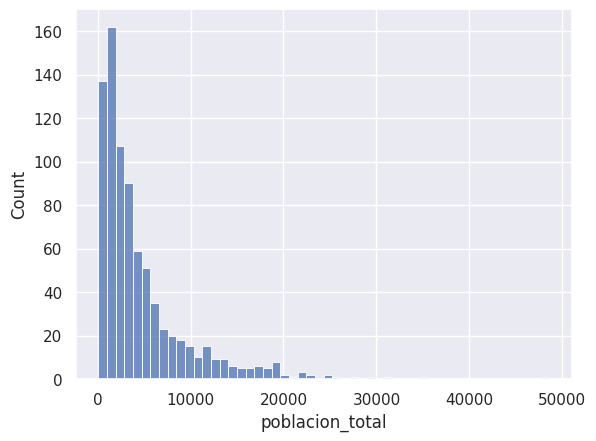

In [21]:
sns.histplot(df_null_urbano, x='poblacion_total'); 

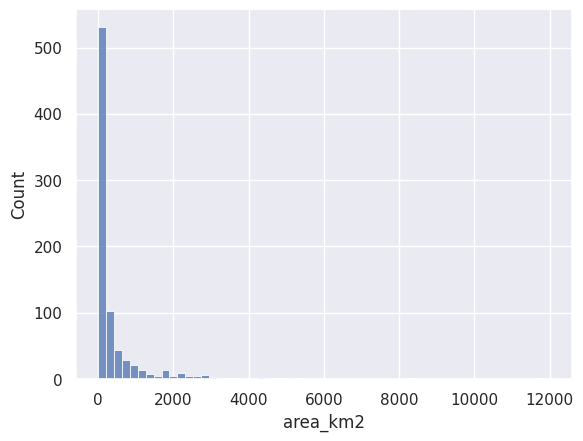

In [22]:
sns.histplot(df_null_urbano, x='area_km2'); 

In [25]:
df_null_urbano[['poblacion_total', 'area_km2']].describe()

,poblacion_total,area_km2
count,811.000000,811.000000
mean,4641.246609,440.245319
std,5201.350529,981.378749
min,81.000000,2.214071
25%,1372.000000,52.607939
50%,2846.000000,123.478805
75%,5758.000000,351.707086
max,48583.000000,11987.599911


El municipio con mayor polación: 

In [27]:
df_null_urbano['poblacion_total'].idxmax()

np.int64(25500)

In [28]:
df.iloc[25500]

año                                                2025
cvegeo                                            10014
total_delitos                                      99.0
poblacion_total                                   48583
indice_marginacion_normalizado_2020            0.441933
porcentaje_analfabetismo                      22.869092
porcentaje_sin_agua_entubada                  50.631232
porcentaje_viviendas_hacinamiento             55.670326
fn_pobreza_porcentaje                              91.1
fn_pobreza_extrema_porcentaje                      65.5
fn_vulnerable_ingresos_porcentaje                   0.7
fn_carencia_seguridad_social_porcentaje            89.1
fn_poblacion                                    49103.0
poblacion_urbano                                    NaN
nomgeo                                        Mezquital
area_km2                                    8283.423005
region                                     centro-norte
zona_metropolitana                              

In [31]:
df_null_urbano['zona_metropolitana'].value_counts()

zona_metropolitana
0    811
Name: count, dtype: int64

In [37]:
pd.DataFrame(df_null_urbano['poblacion_total'] / df_null_urbano['area_km2']).describe()

,0
count,811.000000
mean,46.957492
std,86.710639
min,0.105464
25%,8.194312
50%,23.572472
75%,54.191170
max,1619.937679


In [38]:
ids = ['cvegeo', 'nomgeo']

In [39]:
time = ['año']

In [40]:
target = ['tasa_delitos']

In [41]:
binary = ['zona_metropolitana', 'es_frontera']

In [42]:
categorical = ['region']

In [43]:
numerical = [
    'indice_marginacion_normalizado_2020', 
    'porcentaje_analfabetismo', 
    'porcentaje_sin_agua_entubada', 
    'porcentaje_viviendas_hacinamiento', 
    'fn_pobreza_porcentaje', 
    'fn_pobreza_extrema_porcentaje', 
    'fn_vulnerable_ingresos_porcentaje', 
    'fn_carencia_seguridad_social_porcentaje', 
    'prop_urbano', 
    'poblacion_total', 
    'area_km2'
]

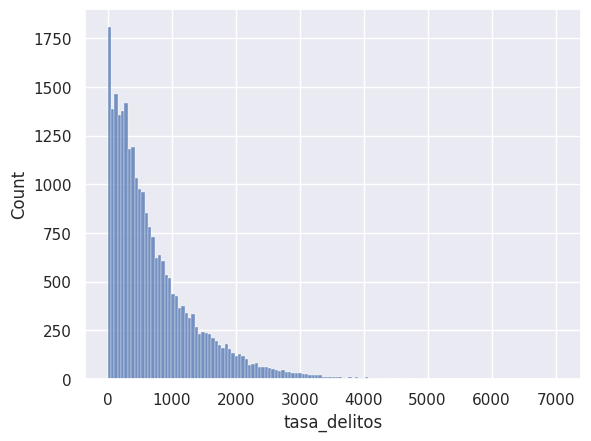

In [44]:
sns.histplot(df['tasa_delitos']); 

In [45]:
df['tasa_delitos'].describe()

count    26038.000000
mean       724.168583
std        698.255746
min          0.000000
25%        226.978175
50%        511.223759
75%       1002.863973
max       7049.299851
Name: tasa_delitos, dtype: float64

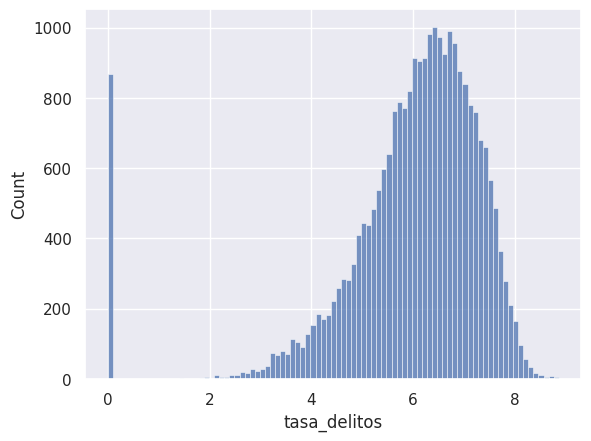

In [47]:
sns.histplot(np.log1p(df['tasa_delitos']));

In [76]:
im = (
    df.query("año == 2025")
    .loc[:, ['indice_marginacion_normalizado_2020']]
)

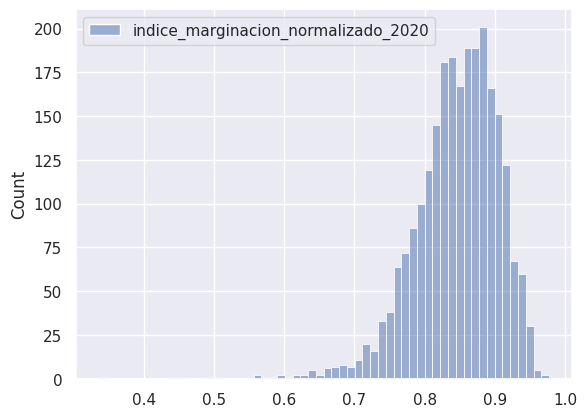

In [77]:
sns.histplot(im); 

In [81]:
analfabetismo = (
    df.query("año == 2025")
    .loc[:, ['porcentaje_analfabetismo']]
)

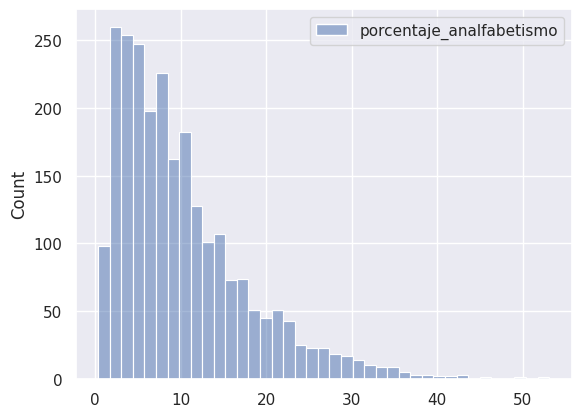

In [82]:
sns.histplot(analfabetismo); 

In [84]:
numerical

['indice_marginacion_normalizado_2020',
 'porcentaje_analfabetismo',
 'porcentaje_sin_agua_entubada',
 'porcentaje_viviendas_hacinamiento',
 'fn_pobreza_porcentaje',
 'fn_pobreza_extrema_porcentaje',
 'fn_vulnerable_ingresos_porcentaje',
 'fn_carencia_seguridad_social_porcentaje',
 'prop_urbano',
 'poblacion_total',
 'area_km2']